# Survival analysis for semiconductor equities

**The research question this repo is built for:** when a semiconductor company
announces a *design win* — its chip designed into a customer's product — how long
until the win shows up as revenue acceleration, and what does the answer imply for
how the market should price these announcements? Time-to-event with incomplete
observation is exactly what survival analysis was invented for: many wins have not
yet ramped when you close the dataset, and throwing those out (or pretending they
ramped at the cutoff) biases everything. The right vocabulary is censoring,
Kaplan-Meier curves, and hazard models.

**The data reality, stated honestly:** design-win announcements cannot be downloaded
from an API — they live in press releases and earnings-call transcripts and must be
hand-collected. This repo therefore does the two things that can be done rigorously
today: (1) it implements and *tests* the survival machinery (Kaplan-Meier and
log-rank from scratch, cross-validated against `lifelines`; Cox regression via
`lifelines`), and (2) it validates that machinery end-to-end on a real, freely
available survival question in the same names: **how long do drawdowns in
semiconductor stocks take to recover?** The design-win corpus schema and loader are
ready (`src/survivalsemi/designwins.py`); collecting the announcements is the
explicit next step.

**Findings on the validation study, up front:** semiconductor names hit 10%
drawdowns constantly and recover in a median of ~34 trading days, versus ~81 for
SPY's much rarer 10% drawdowns — but that comparison is a *threshold artifact*, and
proving so is one of the study's best results: at a volatility-matched threshold the
gap disappears entirely. One finding is real: recoveries are strongly slowed by
concurrent market stress (~24% lower recovery hazard per 10 points of concurrent SPY
drawdown, clustered p ≈ 1e-4). And a deliberately sprung trap shows how a
post-baseline covariate (eventual drawdown depth) manufactures spectacular fake
significance in a Cox model — the single most instructive mistake in applied
survival analysis.

In [1]:
%matplotlib inline
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter

from survivalsemi import KaplanMeier
from survivalsemi.data import load_prices
from survivalsemi.drawdowns import episodes_for_universe, extract_episodes
from survivalsemi.logrank import logrank_test

ASSETS = Path("..") / "assets"
ASSETS.mkdir(exist_ok=True)
plt.rcParams["figure.dpi"] = 110

SEMIS = ["TXN", "ADI", "MCHP", "ON", "NXPI"]
prices = {t: load_prices(t, cache_dir="../data/prices") for t in SEMIS}
spy = load_prices("SPY", cache_dir="../data/prices")

for ticker, series in {**prices, "SPY": spy}.items():
    vol = series.pct_change().std(ddof=1) * np.sqrt(252)
    print(f"{ticker:5s} {series.index[0].date()} -> {series.index[-1].date()}"
          f"  ({len(series):5,} days, full-sample ann vol {vol:.0%})")

TXN   1993-01-04 -> 2026-07-02  (8,432 days, full-sample ann vol 40%)
ADI   1993-01-04 -> 2026-07-02  (8,432 days, full-sample ann vol 44%)
MCHP  1993-03-19 -> 2026-07-02  (8,379 days, full-sample ann vol 48%)
ON    2000-05-02 -> 2026-07-02  (6,581 days, full-sample ann vol 61%)
NXPI  2010-08-06 -> 2026-07-02  (4,000 days, full-sample ann vol 43%)
SPY   1993-01-29 -> 2026-07-02  (8,413 days, full-sample ann vol 19%)


## 1. A two-minute survival-analysis primer

- **Censoring.** An episode still open when the sample ends tells you the duration
  was *at least* that long. Right-censored observations stay in the analysis and
  leave the risk set without contributing an event — no bias, no thrown-away data.
- **Kaplan-Meier.** The nonparametric survival curve: at each event time, multiply by
  (1 − events/at-risk). S(t) = probability an episode lasts longer than t.
- **Log-rank test.** Do two groups share one hazard? Compares observed events per
  group against the expectation under a pooled hazard at every event time.
- **Cox proportional hazards.** Regression on the *hazard* (instantaneous recovery
  rate): hazard ratio exp(β) > 1 means the covariate speeds recovery. Its key rule is
  the one the trap below violates: covariates must be known at baseline.

The KM estimator and log-rank test here are implemented from scratch
(`kaplan_meier.py`, `logrank.py`) and cross-validated against `lifelines` in the test
suite — same discipline as the options library's three-engine cross-check.

## 2. What counts as an episode

An episode opens when a stock closes 10% below its trailing 252-day high and closes
— the *event* — when it regains the high that was in force at entry; deeper drops
before recovery extend the same episode, and an episode still open at sample end is
censored. Baseline covariates (trailing 60-day vol, concurrent SPY drawdown) are
measured at entry only. Here is what that looks like on one name:

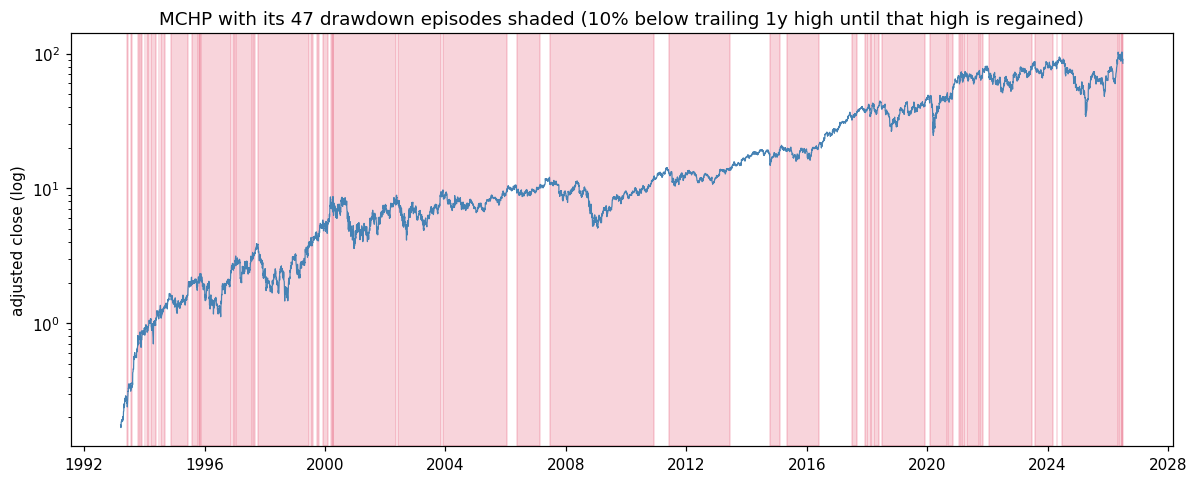

In [2]:
mchp_eps = extract_episodes(prices["MCHP"], threshold=0.10, window=252, market=spy)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.semilogy(prices["MCHP"], lw=0.8, color="steelblue")
for _, ep in mchp_eps.iterrows():
    end = ep.exit_date if ep.recovered else prices["MCHP"].index[-1]
    ax.axvspan(ep.entry_date, end, color="crimson", alpha=0.18)
ax.set_title(f"MCHP with its {len(mchp_eps)} drawdown episodes shaded "
             "(10% below trailing 1y high until that high is regained)")
ax.set_ylabel("adjusted close (log)")
fig.tight_layout()
fig.savefig(ASSETS / "episodes_mchp.png", bbox_inches="tight")
plt.show()

In [3]:
semi_eps = episodes_for_universe(prices, market=spy, threshold=0.10, window=252)
spy_eps = extract_episodes(spy, threshold=0.10, window=252, market=spy)

counts = semi_eps.groupby("ticker").agg(
    episodes=("recovered", "size"),
    recovered=("recovered", "sum"),
    median_duration=("duration_days", "median"),
    median_depth=("max_depth", "median"),
).round(2)
counts.loc["SPY"] = [len(spy_eps), spy_eps.recovered.sum(),
                     spy_eps.duration_days.median(), spy_eps.max_depth.median()]
counts

,episodes,recovered,median_duration,median_depth
ticker,,,,
ADI,48.0,47.0,36.5,0.160000
MCHP,47.0,46.0,40.0,0.190000
NXPI,19.0,18.0,25.0,0.190000
ON,16.0,15.0,20.0,0.200000
TXN,32.0,31.0,24.0,0.140000
SPY,12.0,12.0,97.5,0.188926


The asymmetry that drives everything below: five semiconductor names produced 162
episodes in ~30 years (about one 10% drawdown per name per year — routine weather at
40–60% annualised vol), while SPY produced twelve, several of them multi-year
regime-defining bears (2000, 2008). Same threshold, completely different kind of
event.

## 3. Kaplan-Meier: who recovers faster?

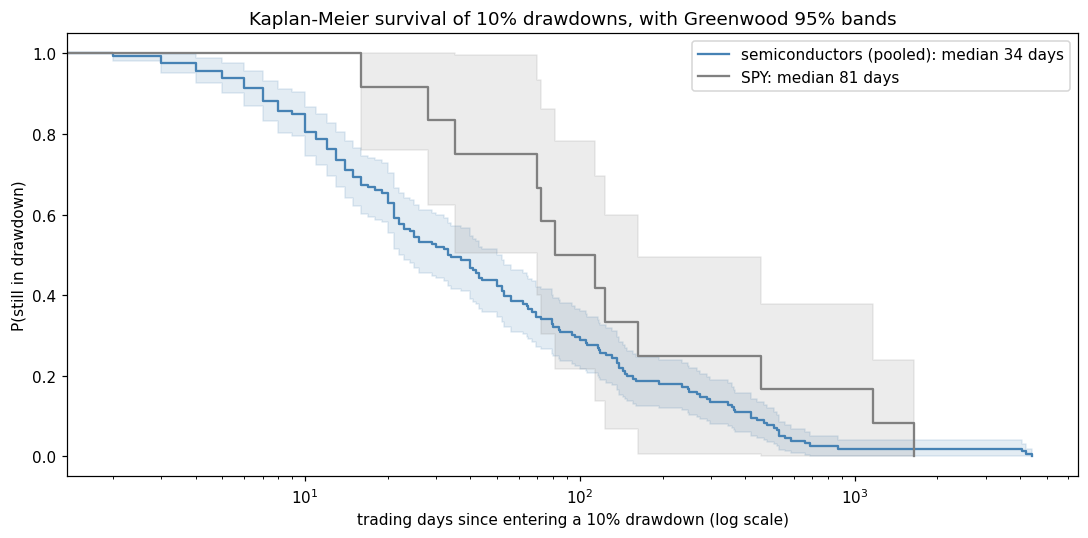

semis:  162 episodes (5 censored), median 34 days,  S(63d)=0.38, S(252d)=0.16
SPY:    12 episodes, median 81 days, S(63d)=0.75,  S(252d)=0.25
log-rank: chi2 = 2.77, p = 0.096


In [4]:
km_semi = KaplanMeier.fit(semi_eps.duration_days, semi_eps.recovered)
km_spy = KaplanMeier.fit(spy_eps.duration_days, spy_eps.recovered)

fig, ax = plt.subplots(figsize=(10, 5))
for km, label, color in [(km_semi, "semiconductors (pooled)", "steelblue"),
                         (km_spy, "SPY", "gray")]:
    band = km.confidence_band()
    times = np.concatenate([[0.0], band.time])
    ax.step(times, np.concatenate([[1.0], band.survival]), where="post",
            label=f"{label}: median {km.median():.0f} days", color=color)
    ax.fill_between(times, np.concatenate([[1.0], band.lower]),
                    np.concatenate([[1.0], band.upper]),
                    step="post", alpha=0.15, color=color)
ax.set_xscale("log")
ax.set_xlabel("trading days since entering a 10% drawdown (log scale)")
ax.set_ylabel("P(still in drawdown)")
ax.set_title("Kaplan-Meier survival of 10% drawdowns, with Greenwood 95% bands")
ax.legend()
fig.tight_layout()
fig.savefig(ASSETS / "km_curves.png", bbox_inches="tight")
plt.show()

lr = logrank_test(semi_eps.duration_days, semi_eps.recovered,
                  spy_eps.duration_days, spy_eps.recovered)
print(f"semis:  {km_semi.n_observations} episodes ({km_semi.n_censored} censored), "
      f"median {km_semi.median():.0f} days,  S(63d)={km_semi.survival_at(63):.2f}, "
      f"S(252d)={km_semi.survival_at(252):.2f}")
print(f"SPY:    {km_spy.n_observations} episodes, median {km_spy.median():.0f} days, "
      f"S(63d)={km_spy.survival_at(63):.2f},  S(252d)={km_spy.survival_at(252):.2f}")
print(f"log-rank: chi2 = {lr.statistic:.2f}, p = {lr.p_value:.3f}")

Taken at face value: semis escape their drawdowns much faster early (a quarter in,
38% of semi episodes are still open versus 75% of SPY's), medians 34 vs 81 trading
days, though the log-rank difference is only marginal (p ≈ 0.10) because SPY
contributes so few episodes.

**But the comparison is rigged by the threshold.** A 10% move is about a quarter of
an annual standard deviation for a 45%-vol semiconductor stock — and more than half
of one for 19%-vol SPY. We are timing recoveries from routine fluctuations in one
group and from genuine market events in the other.

## 4. The severity-matched comparison — the artifact disappears

Match severity instead of percentage: the semis run at roughly 2–3x SPY's vol, so a
20% semi drawdown is comparable, in vol units, to a 10% SPY drawdown.

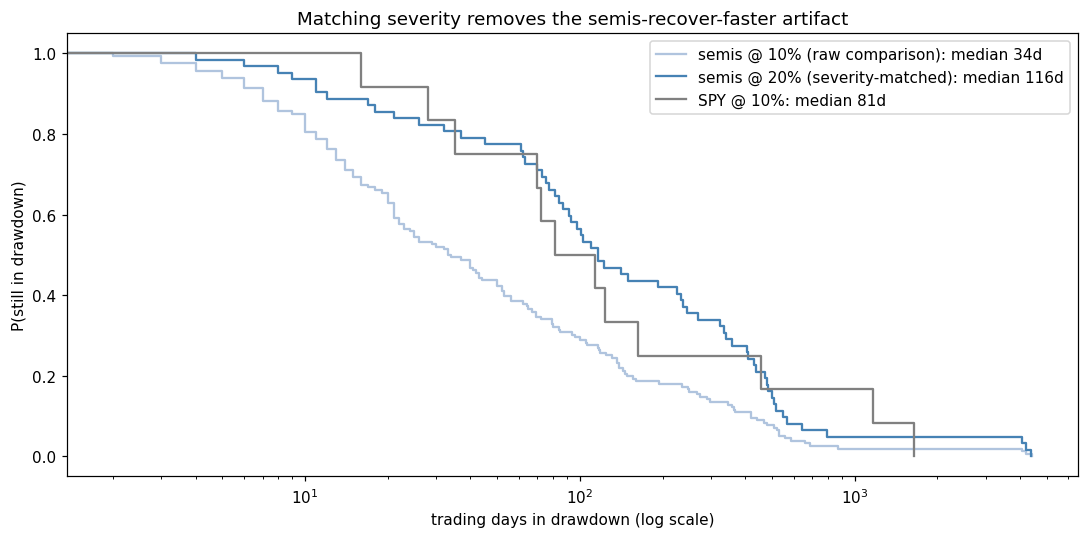

semis @20%: 63 episodes, median 116 days
log-rank vs SPY @10%: chi2 = 0.02, p = 0.874


In [5]:
semi20 = episodes_for_universe(prices, market=spy, threshold=0.20, window=252)
km_semi20 = KaplanMeier.fit(semi20.duration_days, semi20.recovered)

fig, ax = plt.subplots(figsize=(10, 5))
for km, label, color in [(km_semi, "semis @ 10% (raw comparison)", "lightsteelblue"),
                         (km_semi20, "semis @ 20% (severity-matched)", "steelblue"),
                         (km_spy, "SPY @ 10%", "gray")]:
    step = km.as_step()
    ax.step(step.time, step.survival, where="post",
            label=f"{label}: median {km.median():.0f}d", color=color)
ax.set_xscale("log")
ax.set_xlabel("trading days in drawdown (log scale)")
ax.set_ylabel("P(still in drawdown)")
ax.set_title("Matching severity removes the semis-recover-faster artifact")
ax.legend()
fig.tight_layout()
fig.savefig(ASSETS / "km_severity.png", bbox_inches="tight")
plt.show()

lr20 = logrank_test(semi20.duration_days, semi20.recovered,
                    spy_eps.duration_days, spy_eps.recovered)
print(f"semis @20%: {len(semi20)} episodes, median {km_semi20.median():.0f} days")
print(f"log-rank vs SPY @10%: chi2 = {lr20.statistic:.2f}, p = {lr20.p_value:.3f}")

At matched severity the story inverts and then evaporates: semi medians go to ~116
days (longer than SPY's 81), and the log-rank test finds nothing (p ≈ 0.87). The
honest conclusion is that *there was no cross-sectional recovery-speed effect — there
was a threshold-scaling effect*. Catching your own artifact before someone else does
is most of what applied statistics is.

## 5. Cox regression on baseline covariates — one null, one real effect

Within the 162 semi episodes: does entering a drawdown in a high-vol state, or while
the broad market is itself stressed, predict recovery speed? Covariates measured
strictly at entry; standard errors clustered by ticker because episodes across names
share market shocks (2008 hits all five at once — these are not 162 independent
observations).

In [6]:
cox_data = semi_eps[["ticker", "duration_days", "recovered",
                     "trailing_vol", "market_dd"]].dropna()
baseline_model = CoxPHFitter()
baseline_model.fit(cox_data, duration_col="duration_days", event_col="recovered",
                   cluster_col="ticker")
baseline_model.summary[["coef", "exp(coef)", "exp(coef) lower 95%",
                        "exp(coef) upper 95%", "p"]].round(3)

,coef,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
covariate,,,,,
trailing_vol,0.415,1.515,0.769,2.983,0.23
market_dd,-2.773,0.062,0.016,0.247,0.00


Two answers, one null and one real. Trailing volatility at entry predicts nothing
(p ≈ 0.23) — how jumpy the stock was does not tell you how long the hole will take
to climb out of. The concurrent market drawdown, though, is strongly significant
even with ticker-clustered errors: hazard ratio ~0.06 per unit of SPY drawdown,
which works out to roughly a **24% lower recovery hazard per 10 points of concurrent
market drawdown** (exp(−2.77 × 0.1) ≈ 0.76). Economically sensible: a semiconductor
stock cannot regain its high while the tide that dragged it down is still going out —
idiosyncratic dips heal fast, systematic ones wait for the market. One honest caution
on magnitude: the 162 episodes stand behind only about a dozen independent market
regimes, so treat the interval's edges with skepticism even though it excludes 1.

## 6. The trap, sprung on purpose: a post-baseline covariate

Now add the episode's *maximum depth* as a covariate. It feels natural ("deeper
drawdowns take longer") and it is completely invalid: depth is measured over the
episode's future — you cannot know it at entry. Mechanically, an episode that
survives longer has more time to get deeper, and a deeper trough has further to climb
back, so depth is partly an *outcome* dressed as a predictor. Watch it manufacture
certainty:

In [7]:
trap_data = semi_eps[["ticker", "duration_days", "recovered",
                      "trailing_vol", "market_dd", "max_depth"]].dropna()
trap_model = CoxPHFitter()
trap_model.fit(trap_data, duration_col="duration_days", event_col="recovered",
               cluster_col="ticker")

comparison = pd.concat({
    "baseline (valid)": baseline_model.summary[["exp(coef)", "p"]],
    "with max_depth (invalid)": trap_model.summary[["exp(coef)", "p"]],
}, axis=1)
comparison.round(4)

baseline (valid)         with max_depth (invalid)        
                    exp(coef)       p                exp(coef)       p
covariate                                                             
trailing_vol           1.5147  0.2298                  53.8085  0.0000
market_dd              0.0625  0.0001                   0.0151  0.0488
max_depth                 NaN     NaN                   0.0000  0.0000

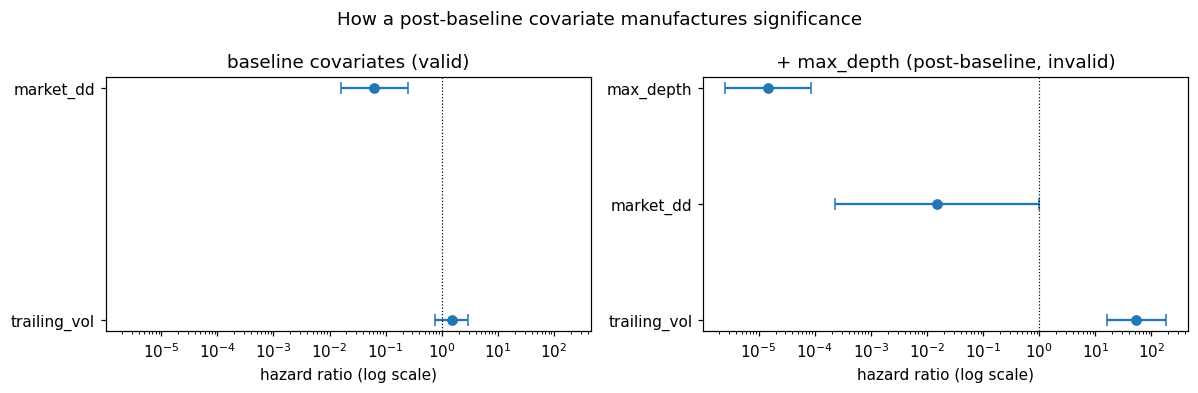

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True)
for ax, model, title in [(axes[0], baseline_model, "baseline covariates (valid)"),
                         (axes[1], trap_model, "+ max_depth (post-baseline, invalid)")]:
    summary = model.summary
    y = np.arange(len(summary))
    ax.errorbar(summary["exp(coef)"], y,
                xerr=[summary["exp(coef)"] - summary["exp(coef) lower 95%"],
                      summary["exp(coef) upper 95%"] - summary["exp(coef)"]],
                fmt="o", capsize=4)
    ax.axvline(1.0, color="black", lw=0.8, ls=":")
    ax.set_yticks(y, summary.index)
    ax.set_xscale("log")
    ax.set_xlabel("hazard ratio (log scale)")
    ax.set_title(title)
fig.suptitle("How a post-baseline covariate manufactures significance")
fig.tight_layout()
fig.savefig(ASSETS / "cox_trap.png", bbox_inches="tight")
plt.show()

The most instructive casualty is `trailing_vol`: honestly null in the valid model
(p ≈ 0.23), it becomes the "strongest predictor in the study" (hazard ratio ≈ 54,
p < 1e-4) the moment the invalid control enters — among episodes forced to the same
final depth, high-vol names bounce back faster, a comparison no forecaster can ever
make because final depth is unknowable at entry. `max_depth` itself reports p ≈ 0
with an absurd hazard ratio. All of it is meaningless, because the model conditions
on the future. This is the survival-analysis version of lookahead bias,
and it is the exact mistake to avoid when the design-win corpus arrives: covariates
like "size of the eventual production ramp" belong to the outcome, not the baseline.
Announcement-date covariates (segment, customer type, issuer, prevailing cycle
conditions) are the valid set.

## 7. The design-win pipeline is ready for data

The schema, loader, and survival-table conversion are implemented and tested. The
template below ships in `data/` — the EXAMPLE rows exist only to show the format and
are not real announcements. Collecting ~50 real announcements from IR archives (with
`revenue_event_date` filled from subsequent earnings calls where observable) is the
data-collection step, and the resulting table feeds the exact KM/log-rank/Cox
machinery validated above, unchanged.

In [9]:
from survivalsemi.designwins import load_designwins, to_survival_table

corpus = load_designwins("../data/design_wins_template.csv")
print(corpus.to_string(index=False))
print()
print(to_survival_table(corpus, as_of="2026-07-01").to_string(index=False))

ticker announce_date                                 customer    segment              source_url revenue_event_date
  MCHP    2024-03-01    EXAMPLE Corp (replace with real rows)       auto https://example.com/pr1         2025-01-15
  NXPI    2024-06-10 EXAMPLE Systems (replace with real rows) industrial https://example.com/pr2                NaT

ticker    segment  duration_days  event
  MCHP       auto            320   True
  NXPI industrial            751  False


## 8. Verdict and limitations

**What this study established:**

1. The survival machinery is correct — from-scratch KM and log-rank match
   `lifelines` to 1e-9 on randomised inputs, and behave right on hand-computed cases.
2. Semiconductor 10% drawdowns are frequent weather (median recovery ~34 trading
   days); SPY 10% drawdowns are rare events (median ~81). The apparent difference is
   a **threshold-scaling artifact** — severity-matched, it vanishes (p ≈ 0.87).
3. Baseline covariates split honestly: entry-time volatility predicts nothing
   (p ≈ 0.23), while concurrent market stress robustly slows recovery — about 24%
   lower recovery hazard per 10 points of concurrent SPY drawdown (clustered
   p ≈ 1e-4), with the regime-count caveat stated.
4. Post-baseline covariates manufacture fake significance — a covariate that was
   honestly null became the study's "strongest predictor" — demonstrated
   deliberately, so the mistake is recognisable before it matters.

**Limitations:** the 10%/252-day episode definition is one arbitrary choice among
many (the 20% robustness check is the mitigation, not the cure); episodes overlap in
calendar time across tickers, so clustering by ticker is a partial fix for
cross-sectional dependence, not a complete one; durations are trading days on
adjusted closes; and five tickers is a narrow universe chosen for the design-win
follow-on rather than for cross-sectional power.

**Next steps:** hand-collect the announcement corpus (the actual research question);
add a Weibull/AFT parametric layer to compare against the nonparametric curves; widen
the universe (SOX constituents) for cross-sectional power.